# Task 3: Energy Consumption Time Series Forecasting

## Problem Statement

Accurately forecasting household energy consumption helps optimize energy usage, improve resource planning, and support smart energy management.

## Objective

The objective of this project is to forecast short-term household energy consumption using historical data and compare different forecasting models.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset

In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df.shape

(652248, 9)

In [4]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652248 entries, 0 to 652247
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   652248 non-null  object 
 1   Time                   652248 non-null  object 
 2   Global_active_power    652247 non-null  object 
 3   Global_reactive_power  652247 non-null  object 
 4   Voltage                652247 non-null  object 
 5   Global_intensity       652247 non-null  object 
 6   Sub_metering_1         652247 non-null  object 
 7   Sub_metering_2         652247 non-null  object 
 8   Sub_metering_3         648308 non-null  float64
dtypes: float64(1), object(8)
memory usage: 44.8+ MB


In [6]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,1
Global_reactive_power,1
Voltage,1
Global_intensity,1
Sub_metering_1,1
Sub_metering_2,1
Sub_metering_3,3940


## Data Preprocessing

In [7]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

In [8]:
df = df.drop(columns=['Date', 'Time'])

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00


In [9]:
df.set_index('Datetime', inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [10]:
df = df.replace('?', np.nan)

In [11]:
df = df.astype(float)

In [12]:
df.isnull().sum()

,0
Global_active_power,3940
Global_reactive_power,3940
Voltage,3940
Global_intensity,3940
Sub_metering_1,3940
Sub_metering_2,3940
Sub_metering_3,3940


In [13]:
df = df.fillna(method='ffill')

/tmp/ipykernel_499/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [14]:
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


## Resampling Time Series

In [15]:
daily_data = df.resample('D').mean()

daily_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


In [16]:
daily_data.shape

(454, 7)

## Feature Engineering

In [17]:
daily_data['Hour'] = daily_data.index.hour
daily_data['DayOfWeek'] = daily_data.index.dayofweek
daily_data['Month'] = daily_data.index.month
daily_data['Year'] = daily_data.index.year

daily_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,DayOfWeek,Month,Year
Datetime,,,,,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394,0,5,12,2006
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583,0,6,12,2006
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722,0,0,12,2006
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472,0,1,12,2006
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972,0,2,12,2006


## Exploratory Data Analysis

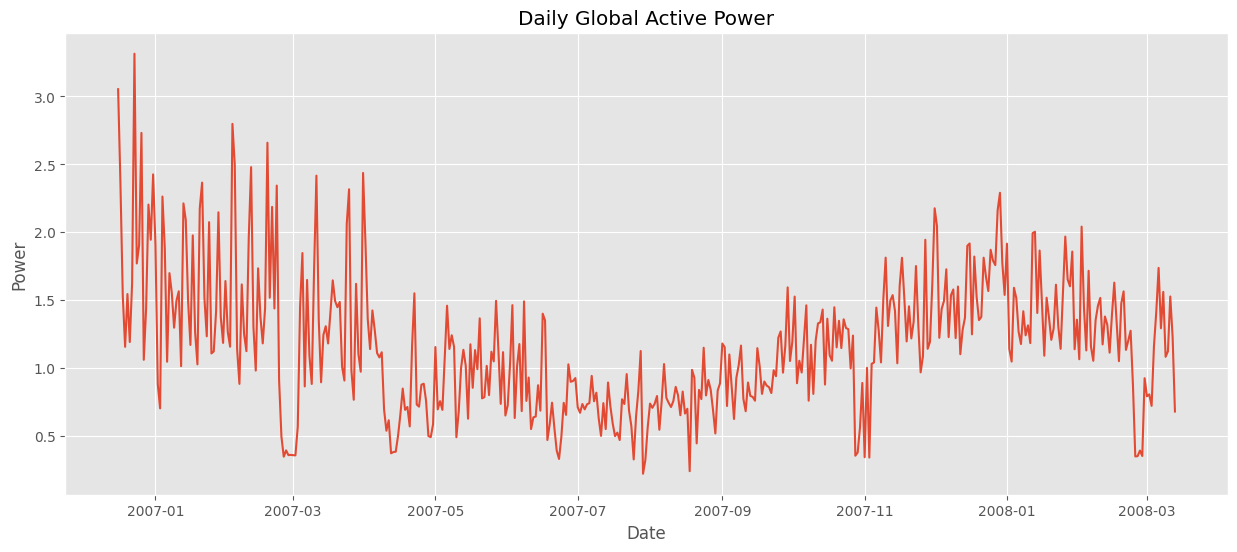

In [18]:
plt.figure(figsize=(15,6))

plt.plot(daily_data['Global_active_power'])

plt.title("Daily Global Active Power")

plt.xlabel("Date")

plt.ylabel("Power")

plt.show()

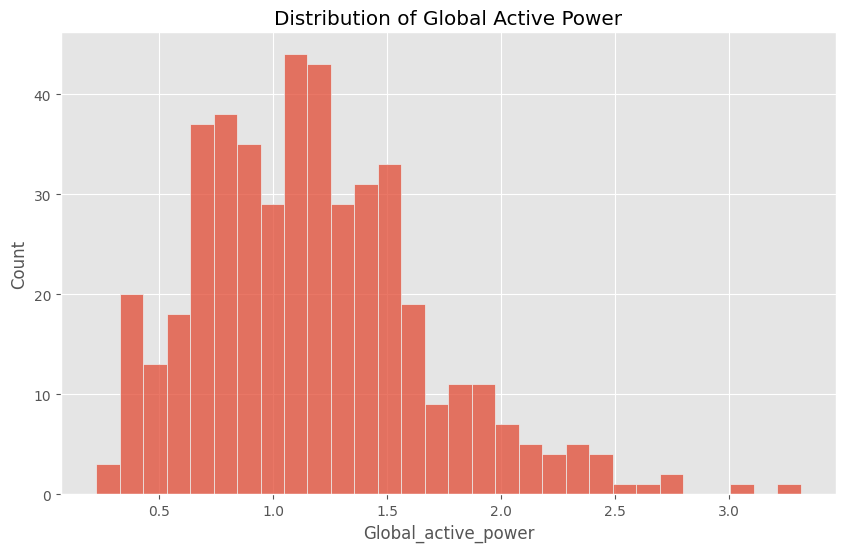

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    daily_data['Global_active_power'],
    bins=30
)

plt.title("Distribution of Global Active Power")

plt.show()

In [20]:
!pip install prophet xgboost -q

In [21]:
from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

## Train-Test Split

In [22]:
target = daily_data['Global_active_power']

train_size = int(len(target) * 0.8)

train = target[:train_size]

test = target[train_size:]

print("Training Samples:", len(train))
print("Testing Samples:", len(test))

Training Samples: 363
Testing Samples: 91


## ARIMA Model

In [23]:
arima_model = ARIMA(train, order=(5,1,0))

arima_model_fit = arima_model.fit()

In [24]:
arima_pred = arima_model_fit.forecast(steps=len(test))

In [25]:
arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 0.3013029625034534
ARIMA RMSE: 0.3931268335046013


## Prophet Model

In [26]:
prophet_df = daily_data.reset_index()[['Datetime', 'Global_active_power']]

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


In [27]:
train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

In [28]:
prophet_model = Prophet()

prophet_model.fit(train_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [29]:
future = prophet_model.make_future_dataframe(periods=len(test_prophet))

forecast = prophet_model.predict(future)

In [30]:
prophet_pred = forecast['yhat'].tail(len(test_prophet)).values

In [31]:
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred)

prophet_rmse = np.sqrt(
    mean_squared_error(test_prophet['y'], prophet_pred)
)

print("Prophet MAE:", prophet_mae)

print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 0.4052616928772881
Prophet RMSE: 0.5218241540126527


## XGBoost Model

In [32]:
xgb_data = daily_data.copy()

xgb_data['Target'] = xgb_data['Global_active_power']

xgb_data = xgb_data.dropna()

In [33]:
features = ['DayOfWeek', 'Month', 'Year']

X = xgb_data[features]

y = xgb_data['Target']

In [34]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [35]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [36]:
xgb_pred = xgb_model.predict(X_test)

In [37]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 0.369009749491589
XGBoost RMSE: 0.4617032357482427


## Model Comparison

In [38]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [arima_mae, prophet_mae, xgb_mae],
    'RMSE': [arima_rmse, prophet_rmse, xgb_rmse]
})

comparison

,Model,MAE,RMSE
0,ARIMA,0.301303,0.393127
1,Prophet,0.405262,0.521824
2,XGBoost,0.369010,0.461703


## Actual vs Forecast

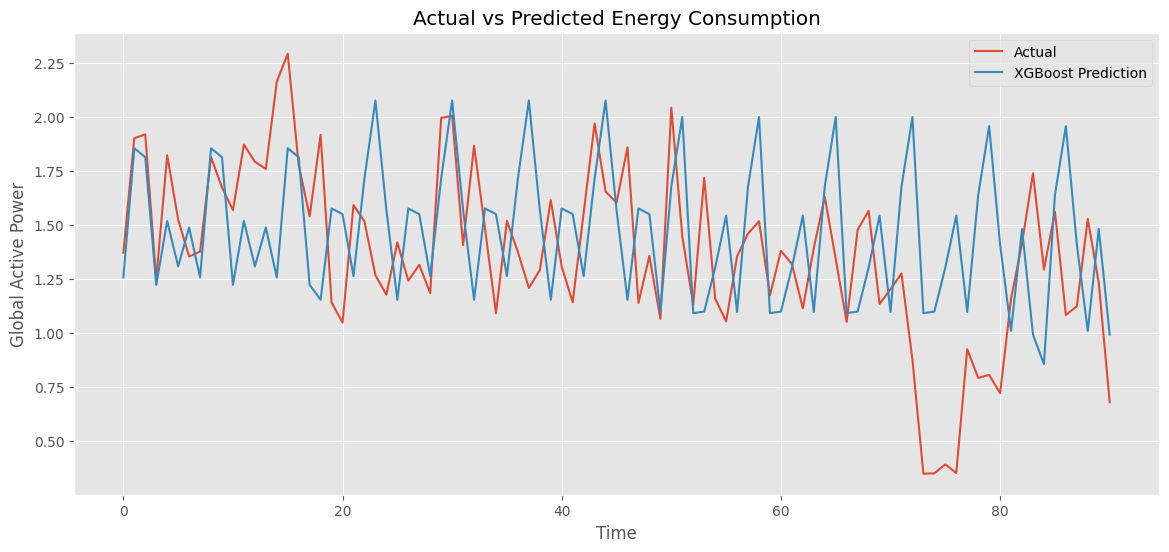

In [39]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label='Actual')

plt.plot(xgb_pred, label='XGBoost Prediction')

plt.legend()

plt.title("Actual vs Predicted Energy Consumption")

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.show()

# Conclusion

In this project, household energy consumption was forecasted using three different forecasting techniques: ARIMA, Prophet, and XGBoost.

The dataset was cleaned, missing values were handled, and the time series was resampled to daily observations. Time-based features were also engineered to support machine learning.

After evaluating the models using MAE and RMSE, ARIMA produced the lowest error among the tested models, indicating the best forecasting performance on this dataset. Prophet also performed well, while XGBoost provided a machine learning-based forecasting approach.

Overall, this project demonstrated the complete workflow of time series forecasting, including preprocessing, feature engineering, model development, evaluation, and visualization.